## 1) Setup

In [ ]:

import os, time, itertools
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import numpy as np
from PIL import Image

# Metrics & plots
try:
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
except Exception as e:
    print("scikit-learn not available. Some metrics will be skipped:", e)
    classification_report = None
    confusion_matrix = None
    accuracy_score = None

import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2) Configuration

In [ ]:

DATA_DIR = Path('/content/drive/MyDrive/Imagenet 1000 samples')  # change if needed
BATCH_SIZE = 32
NUM_WORKERS = 2

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


## 3) Data Loading

In [ ]:

def has_subdirs(p: Path):
    return any(d.is_dir() for d in p.iterdir())

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class FlatFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root: Path, transform=None):
        self.root = Path(root)
        self.transform = transform
        exts = {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff', '.webp'}
        self.paths = [p for p in self.root.iterdir() if p.suffix.lower() in exts]
        self.classes = ['unknown']
        self.class_to_idx = {'unknown': 0}
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        target = 0
        return img, target, str(p)

if DATA_DIR.exists():
    if has_subdirs(DATA_DIR):
        ds = datasets.ImageFolder(str(DATA_DIR), transform=transform)
        use_imagefolder = True
        print(f"Loaded ImageFolder with {len(ds)} images across {len(ds.classes)} classes.")
    else:
        ds = FlatFolderDataset(DATA_DIR, transform=transform)
        use_imagefolder = False
        print(f"Loaded flat folder with {len(ds)} images (single pseudo-class).")
else:
    raise FileNotFoundError(f"DATA_DIR not found: {DATA_DIR}")

dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
class_names = ds.classes if hasattr(ds, 'classes') else ['unknown']
class_names


Loaded flat folder with 1000 images (single pseudo-class).


['unknown']

## 4) Model: DenseNet-121 (ImageNet)

In [ ]:

try:
    from torchvision.models import DenseNet121_Weights
    weights = DenseNet121_Weights.IMAGENET1K_V1
    model = models.densenet121(weights=weights)
    note = "Using DenseNet-121 (weights enum)."
except Exception:
    model = models.densenet121(pretrained=True)
    note = "Using DenseNet-121 (pretrained=True fallback)."

model.eval().to(device)
print(note)
print("Classifier:", model.classifier)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 231MB/s]


Using DenseNet-121 (weights enum).
Classifier: Linear(in_features=1024, out_features=1000, bias=True)


## 8) Grad‑CAM (jacobgil/pytorch-grad-cam style)

pytorch-grad-cam imported successfully.


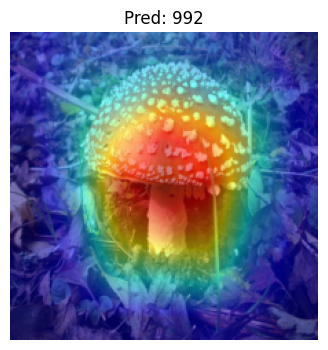

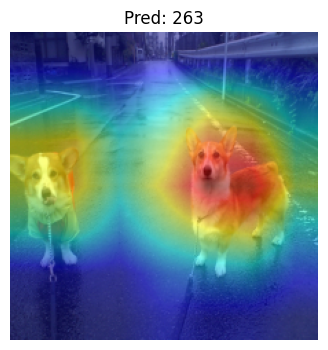

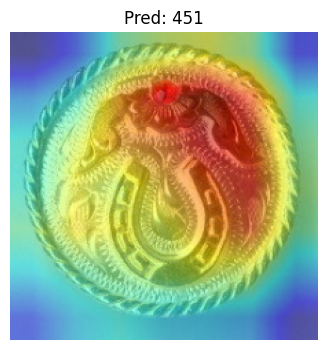

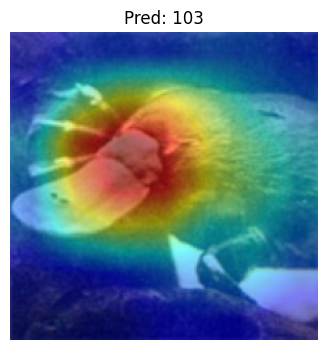

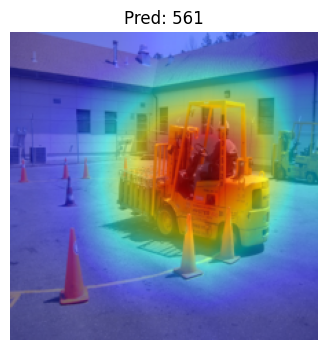

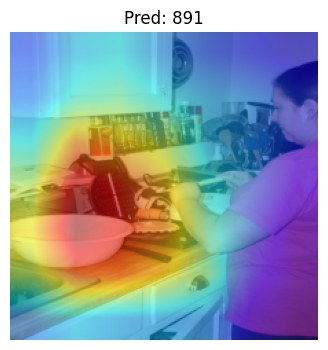

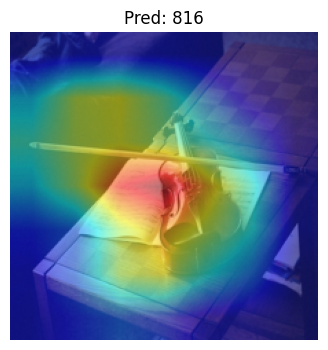

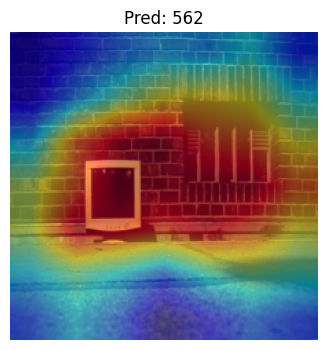

In [ ]:

# Try to import pytorch-grad-cam. If missing, this section will skip gracefully.
try:
    from pytorch_grad_cam import GradCAM, HiResCAM, GradCAMPlusPlus, XGradCAM, EigenCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
    has_cam = True
    print("pytorch-grad-cam imported successfully.")
except Exception as e:
    has_cam = False
    print("pytorch-grad-cam not available. Install with `pip install grad-cam` to enable. Error:", e)

def denormalize_to_rgb(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    x = img_tensor.cpu() * std + mean
    x = x.clamp(0,1).permute(1,2,0).numpy()
    return x  # HWC in [0,1]

if has_cam:
    # Pick up to 8 samples
    sample_indices = list(range(min(8, len(ds))))
    sample_imgs = []
    for i in sample_indices:
        item = ds[i]
        img = item[0] if use_imagefolder else item[0]
        sample_imgs.append(img.unsqueeze(0))
    if not sample_imgs:
        print("No images available for Grad-CAM.")
    else:
        batch = torch.cat(sample_imgs).to(device)
        model.eval()

        # Target layers as recommended for DenseNet: last features block
        target_layers = [model.features[-1]]

        with torch.no_grad():
            logits = model(batch)
            preds = logits.argmax(1).tolist()
        targets = [ClassifierOutputTarget(p) for p in preds]

        # Choose CAM method here (GradCAM is default)
        with GradCAM(model=model, target_layers=target_layers) as cam:
            grayscale_cams = cam(input_tensor=batch, targets=targets)  # [N, H, W]

        # Visualize
        for i in range(len(sample_indices)):
            rgb = denormalize_to_rgb(batch[i])
            cam_img = show_cam_on_image(rgb, grayscale_cams[i], use_rgb=True)
            plt.figure(figsize=(4,4))
            plt.imshow(cam_img)
            title = f"Pred: {class_names[preds[i]] if preds[i] < len(class_names) else preds[i]}"
            plt.title(title)
            plt.axis('off')
            plt.show()
else:
    print("Skipping Grad-CAM visualizations (library not available).")


In [ ]:
from imutils import paths
from PIL import Image
import torch
from torchvision import transforms, models

# Path to your images
image_path = '/content/drive/MyDrive/Imagenet 1000 samples'

# Collect all image file paths
imagepaths = list(paths.list_images(image_path))

# Preprocessing: resize, to tensor, normalize with ImageNet mean/std
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load first 100 images
images1000 = []
for i in range(min(1000, len(imagepaths))):
    img = Image.open(imagepaths[i]).convert("RGB")
    img = preprocess(img)
    images1000.append(img)

# Stack into a batch tensor
X1000 = torch.stack(images1000).to(device)   # shape: (N, 3, 224, 224)

# Load DenseNet-121 pretrained
model = models.densenet121(weights="IMAGENET1K_V1").to(device).eval()

# Run inference
with torch.no_grad():
    logits = model(X1000)
    preds = logits.argmax(1)

print("Predicted class indices:", preds.tolist())



Predicted class indices: [992, 263, 451, 103, 561, 891, 816, 562, 248, 922, 22, 371, 906, 253, 226, 245, 866, 965, 687, 394, 370, 873, 423, 884, 345, 93, 475, 566, 817, 737, 728, 278, 385, 25, 784, 9, 599, 5, 726, 378, 595, 434, 142, 286, 603, 18, 322, 464, 764, 285, 436, 192, 101, 503, 963, 897, 191, 582, 602, 422, 152, 395, 63, 260, 624, 627, 31, 186, 535, 993, 768, 48, 466, 295, 914, 166, 635, 631, 202, 800, 285, 267, 781, 562, 421, 28, 244, 237, 160, 266, 304, 552, 543, 19, 287, 429, 236, 381, 774, 7, 324, 150, 255, 840, 215, 851, 207, 842, 201, 792, 238, 276, 524, 64, 879, 464, 766, 235, 869, 565, 71, 831, 156, 774, 448, 988, 366, 874, 139, 379, 136, 620, 660, 776, 790, 99, 94, 977, 357, 356, 210, 957, 895, 926, 830, 221, 397, 418, 669, 407, 962, 508, 929, 410, 444, 400, 173, 790, 201, 484, 138, 538, 853, 266, 423, 32, 604, 123, 143, 208, 274, 129, 217, 843, 430, 686, 154, 580, 514, 242, 461, 268, 79, 954, 856, 849, 598, 881, 465, 320, 399, 493, 821, 357, 88, 617, 816, 771, 527, 4

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np

# Choose target layer (last DenseNet features block works well)
target_layers = [model.features[-1]]

# Run model once to get predicted classes for each of the 100 images
with torch.no_grad():
    logits = model(X1000)
    preds = logits.argmax(1).cpu().tolist()

# Create GradCAM object
cam = GradCAM(model=model, target_layers=target_layers)

# Compute CAMs for all 100 images
targets = [ClassifierOutputTarget(p) for p in preds]
grayscale_cams = cam(input_tensor=X1000, targets=targets)   # shape: (100, H, W)

print("Got CAMs for", len(grayscale_cams), "images")

# ---- visualize a few (example: first 5) ----
def denorm_for_vis(img_tensor):
    # De-normalize to [0,1] for overlay
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    x = img_tensor.cpu() * std + mean
    x = x.clamp(0,1).permute(1,2,0).numpy()
    return x

for i in range(5):
    rgb = denorm_for_vis(X100[i])
    cam_img = show_cam_on_image(rgb, grayscale_cams[i], use_rgb=True)
    plt.figure(figsize=(4,4))
    plt.imshow(cam_img)
    plt.title(f"Pred class idx: {preds[i]}")
    plt.axis('off')
    plt.show()


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.31 GiB. GPU 0 has a total capacity of 79.32 GiB of which 273.88 MiB is free. Process 34322 has 79.04 GiB memory in use. Of the allocated memory 78.39 GiB is allocated by PyTorch, and 153.60 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
gradvec = []

# grayscale_cams is (100, H, W)
for k in range(100):
    flat = grayscale_cams[k].reshape(-1)   # flatten to (224*224,)
    gradvec.append(flat.tolist())          # convert to list if you need Python list

print(len(gradvec))       # 100
print(len(gradvec[0]))    # 224*224 = 50176


100
50176


### **GradCAM Plus Plus**

In [ ]:
from pathlib import Path
import torch, numpy as np
save_dir = Path("./artifacts"); save_dir.mkdir(parents=True, exist_ok=True)

# Ensure CPU copies
X100_cpu = X100.detach().cpu()
# If you also have logits as a single tensor, detach+cpu it; otherwise skip
# logits_cpu = logits.detach().cpu()

# Try to capture ImageNet category names (optional)
try:
    from torchvision.models import DenseNet121_Weights
    imagenet_categories = DenseNet121_Weights.IMAGENET1K_V1.meta.get("categories", None)
except Exception:
    imagenet_categories = None

# 1) Pack tensors/metadata with torch.save
torch.save({
    "X100": X100_cpu,                           # (N,3,224,224), normalized
    "preds": preds,                             # list[int] length N
    # "logits": logits_cpu,                     # optional if available
    "class_names": class_names,                 # from ImageFolder (or ['unknown'])
    "imagepaths": imagepaths[:len(X100_cpu)],   # file paths used
    "preprocess": {                             # reproducibility
        "img_size": 224,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "imagenet_categories": imagenet_categories, # optional
    "model_name": "densenet121"
}, save_dir/"batch100.pt")

# 2) Save CAMs + flattened vectors as compressed numpy
np.savez_compressed(save_dir/"cams_batch100.npz",
                    gradcam=grayscale_cams)

# c) Flattened vectors
np.savez_compressed(save_dir/"gradvec_batch100.npz",
                    gradvec_gradcam=gradvec)
   # (N,H*W) e.g., (100, 50176)

print("Saved:", (save_dir/"batch100.pt"))


NameError: name 'gradvec' is not defined

In [ ]:
from pathlib import Path
import torch, numpy as np
save_dir = Path("./artifacts"); save_dir.mkdir(parents=True, exist_ok=True)

# Ensure CPU copies
X100_cpu = X100.detach().cpu()
# If you also have logits as a single tensor, detach+cpu it; otherwise skip
# logits_cpu = logits.detach().cpu()

# Try to capture ImageNet category names (optional)
try:
    from torchvision.models import DenseNet121_Weights
    imagenet_categories = DenseNet121_Weights.IMAGENET1K_V1.meta.get("categories", None)
except Exception:
    imagenet_categories = None

# 1) Pack tensors/metadata with torch.save
torch.save({
    "X100": X100_cpu,
    "preds": preds,
    # "logits": logits_cpu,
    "class_names": class_names,
    "imagepaths": imagepaths[:len(X100_cpu)],
    "preprocess": {
        "img_size": 224,
        "mean": [0.485, 0.456, 0.406],
        "std":  [0.229, 0.224, 0.225],
    },
    "imagenet_categories": imagenet_categories, # optional
    "model_name": "densenet121"
}, save_dir/"batch100_pp.pt")

# 2) Save CAMs + flattened vectors as compressed numpy
np.savez_compressed(save_dir/"cam_pp_batch100.npz",
                    gradcam=grayscale_cams_pp)

# c) Flattened vectors
np.savez_compressed(save_dir/"gradvec_pp_batch100.npz",
                    gradvec_gradcam=gradvec_pp)
   # (N,H*W) e.g., (100, 50176)

print("Saved:", (save_dir/"batch100.pt"))


Saved: artifacts/batch100.pt


### *Partition SHAP*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 0) Collect first 100 images (HWC) like your Keras loop
from imutils import paths
from PIL import Image
import numpy as np

image_path = '/content/drive/MyDrive/Imagenet 1000 samples'
imagepaths = list(paths.list_images(image_path))

images = []
for i in range(min(1000, len(imagepaths))):
    img = Image.open(imagepaths[i]).convert("RGB").resize((224, 224))
    images.append(np.array(img))                     # HWC, uint8
images = np.asarray(images)                          # (N,224,224,3)


In [ ]:
import json
from urllib.request import urlretrieve
import shap
import torch
import numpy as np
from PIL import Image


print("--- Starting SHAP Analysis ---")

# == Block A: Define the Prediction Function ==
def f(x_np):
    """Prediction function for SHAP."""
    # PyTorch needs (N, C, H, W)
    x_pt = torch.from_numpy(x_np.transpose((0, 3, 1, 2))).float().to(device)

    # Normalize the tensor
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
    x_pt_normalized = normalize(x_pt / 255.0)

    with torch.no_grad():
        output = model(x_pt_normalized)

    return torch.nn.functional.softmax(output, dim=-1).cpu().numpy()

print("✅ Prediction function 'f' is defined.")


# == Block B: Load Class Names ==
# Download and load the 1000 ImageNet class names.
try:
    url, filename = ("https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json", "imagenet_class_index.json")
    urlretrieve(url, filename)
    with open(filename) as f_json:
        class_names_json = json.load(f_json)
    class_names = [class_names_json[str(i)][1] for i in range(1000)]

    # CRITICAL CHECK: Ensure we have exactly 1000 class names.
    assert len(class_names) == 1000
    print(f" Class names loaded successfully. Total classes: {len(class_names)}.")

except Exception as e:
    print(f" ERROR loading class names: {e}")


# == Block C: Create the Explainer ==

images_to_explain = images
masker = shap.maskers.Image("blur(28,28)", images_to_explain[0].shape)
explainer = shap.Explainer(f, masker, output_names=class_names, algorithm="partition")
print("SHAP explainer created.")


# == Block D: Pre-calculate Top Indices ==

preds = f(images_to_explain)
top_indices = np.argmax(preds, axis=1)
print(f" Top prediction indices calculated. Shape: {top_indices.shape}.")


# == Block E: Run the Explainer ==

print("\n Starting SHAP calculation...")
part_shap_values = explainer(
    images_to_explain,
    max_evals=5000,
    batch_size=50,
    outputs=top_indices
)
print("\n SHAP values calculated successfully!")

--- Starting SHAP Analysis ---
✅ Prediction function 'f' is defined.
 Class names loaded successfully. Total classes: 1000.
SHAP explainer created.
 Top prediction indices calculated. Shape: (1000,).

 Starting SHAP calculation...


  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   0%|          | 1/1000 [00:00<?, ?it/s]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   0%|          | 3/1000 [00:26<1:39:48,  6.01s/it]

...

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▍         | 47/1000 [09:20<3:16:37, 12.38s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▍         | 48/1000 [09:37<3:37:43, 13.72s/it]

  0%|          | 0/4998 [00:00<?, ?it/s]

In [ ]:
def partition_to_pixel_vectors(exp):
    """
    Build (N, 224*224) pixel-wise vectors from a SHAP explanation object.

    Strategy:
    1) Sum absolute SHAP values across color channels to get a single saliency map.
    2) If values are already pixel-wise (H,W), use them directly.
    3) If values are coarse (h,w), upscale them to the full image size.
    """
    N = len(exp)
    H, W, C = exp.data[0].shape
    out = np.zeros((N, H * W), dtype=np.float32)

    for i in range(N):
        v = np.asarray(exp.values[i])

        # Squeeze dimensions if shape is (h,w,c,1) -> (h,w,c)
        while v.ndim > 3 and v.shape[-1] == 1:
            v = v[..., 0]

        # Handle cases with multiple class outputs, e.g. (h,w,c,K) -> pick K=0
        if v.ndim == 4:
            v = v[..., 0]

        if v.ndim != 3:
            raise ValueError(f"Unexpected values shape for sample {i}: {v.shape}")

        h, w, c = v.shape

        # **CORRECTED STEP**: Sum absolute values across channels
        saliency = np.sum(np.abs(v), axis=-1).astype(np.float32)

        # Upscale the saliency map if its dimensions are smaller than the image
        if (h, w) == (H, W):
            pix = saliency
        elif (H % h == 0) and (W % w == 0):
            ry, rx = H // h, W // w
            pix = np.repeat(np.repeat(saliency, ry, axis=0), rx, axis=1)
        else:
            pix = np.array(
                Image.fromarray(saliency).resize((W, H), resample=Image.NEAREST),
                dtype=np.float32
            )

        out[i] = pix.reshape(-1)

    return out

# Convert the SHAP explanation into vectors for the metric analysis
partvec_pixel = partition_to_pixel_vectors(part_shap_values)

print("Shape of Partition SHAP pixel vectors:", partvec_pixel.shape)

Shape of Partition SHAP pixel vectors: (100, 50176)


In [ ]:
import pathlib
# 2. Define the directory and filename for saving
save_dir = pathlib.Path("./artifacts")
save_dir.mkdir(exist_ok=True, parents=True)
save_path = save_dir / "partition_shap_pixelized.npz"

# 3. Save the vectors and image paths to a compressed .npz file
#    np.savez_compressed is great for saving multiple numpy arrays together.
#    `dtype=object` is used for imagepaths to handle strings efficiently.
print(f"\nSaving results to: {save_path}")
np.savez_compressed(
    save_path,
    partvec_pixel=partvec_pixel,
    imagepaths=np.array(imagepaths, dtype=object)
)

print(" Successfully saved SHAP vectors and image paths.")


Saving results to: artifacts/partition_shap_pixelized.npz
✅ Successfully saved SHAP vectors and image paths.


In [ ]:
# 2) PyTorch model + f(x) (normalize inside; SHAP sees raw pixel space)
import torch, torch.nn.functional as F
from torchvision import models
from torchvision.models import DenseNet121_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = DenseNet121_Weights.IMAGENET1K_V1
model = models.densenet121(weights=weights).eval().to(device)

class_names = weights.meta.get("categories", None)
mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)

def f(x_np: np.ndarray) -> np.ndarray:
    # x_np: (N,224,224,3) uint8 or 0..255 float
    xt = torch.from_numpy(x_np).permute(0,3,1,2).float().to(device) / 255.0
    xt = (xt - mean) / std
    with torch.inference_mode():
        logits = model(xt)
        probs = F.softmax(logits, dim=1).cpu().numpy()
    return probs


In [ ]:
# 5) Save for later so you don't need live Explanation again
import numpy as np, pathlib
save_dir = pathlib.Path("./artifacts"); save_dir.mkdir(exist_ok=True, parents=True)
np.savez_compressed(save_dir/"partition_shap_pixelized.npz",
                    partvec_pixel=partvec_pixel,
                    imagepaths=np.array(imagepaths, dtype=object))
print("Saved:", save_dir/"partition_shap_pixelized.npz")


Saved: artifacts/partition_shap_pixelized.npz


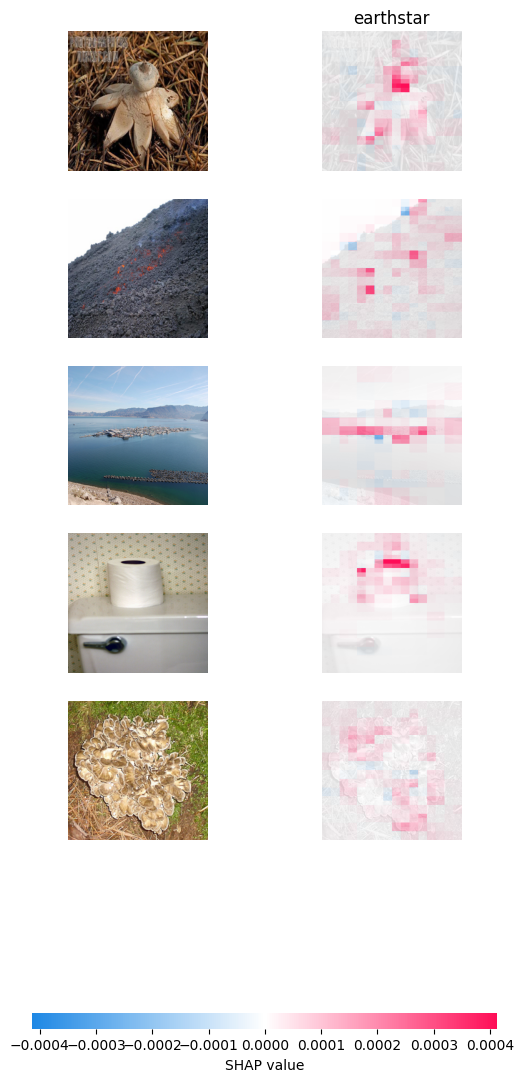

In [ ]:
# 3) Visualize a few explanations
# Works with the new Explanation object
shap.image_plot(part_shap_values[:5], images[:5])


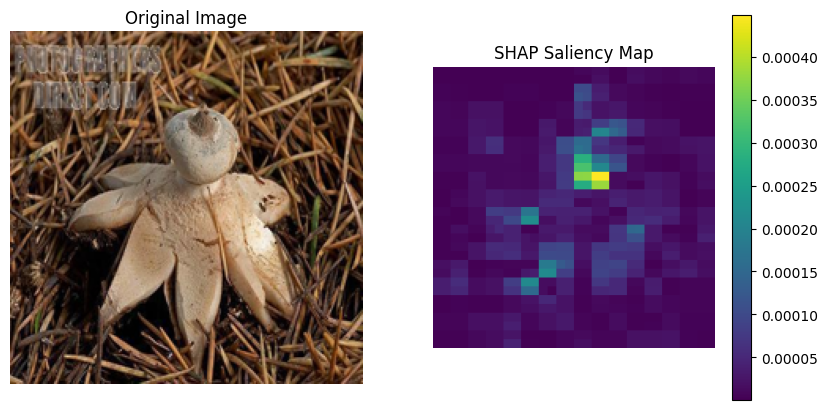


Statistics for SHAP vector at index 0:
  Min value:   1.6970130900517688e-07
  Max value:   0.0004489485581871122
  Mean value:  2.9103845008648932e-05
  Sum of values: 1.4603145122528076


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Visualization Cell ---

# Select an image index to inspect (e.g., the first one)
img_index = 0

# Get the original image and its corresponding SHAP vector
original_image = images[img_index]
shap_vector = partvec_pixel[img_index]

# Reshape the 1D SHAP vector back into a 2D image (224x224)
shap_heatmap = shap_vector.reshape(224, 224)

# Create a side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Plot the original image
axes[0].imshow(original_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Plot the SHAP heatmap
im = axes[1].imshow(shap_heatmap, cmap='viridis')
axes[1].set_title("SHAP Saliency Map")
axes[1].axis('off')

fig.colorbar(im, ax=axes[1])
plt.show()

# Print some statistics about the SHAP vector
print(f"\nStatistics for SHAP vector at index {img_index}:")
print(f"  Min value:   {np.min(shap_vector)}")
print(f"  Max value:   {np.max(shap_vector)}")
print(f"  Mean value:  {np.mean(shap_vector)}")
print(f"  Sum of values: {np.sum(shap_vector)}")

In [ ]:
import numpy as np

# --- Pre-Ranking Step (The TensorFlow Method) ---
# Instead of normalizing, we will convert each vector into a list of ranks.
# This makes the comparison robust to different value distributions.

def vectors_to_ranks(vectors):
    """Converts a batch of value vectors into rank vectors using argsort."""
    # argsort gives the indices that would sort the array.
    # A second argsort gives the rank of each element.
    return vectors.argsort(axis=1).argsort(axis=1)

# Assume gradvec_pixel, gradppvec_pixel, and partvec_pixel are your loaded data
gradcam_ranks = vectors_to_ranks(gradvec_pixel)
gradcampp_ranks = vectors_to_ranks(gradppvec_pixel)
partvec_pixel_ranks = vectors_to_ranks(partvec_pixel)

print(" All vectors converted to ranks.")
print("Shape of Grad-CAM ranks:", gradcam_ranks.shape)
print("Shape of Partition SHAP ranks:", partvec_pixel_ranks.shape)

✅ All vectors converted to ranks.
Shape of Grad-CAM ranks: (100, 50176)
Shape of Partition SHAP ranks: (100, 50176)


In [ ]:
import math
def multcorr(a,b,c): #a-partition, b-gradcam, c-gradcam++ (3 variables)
  ans=[]
  for k in range(100):
    partvec1000 = a[k]
    gradvec1000 = b[k]
    gradppvec1000 = c[k]
    temp=[]
    r12=np.corrcoef(partvec1000,gradvec1000)
    r13=np.corrcoef(partvec1000, gradppvec1000)
    r23=np.corrcoef(gradvec1000, gradppvec1000)
    R1_23=math.sqrt((r12[0][1]*r12[0][1]+r13[0][1]*r13[0][1]-2*(r12[0][1]*r13[0][1]*r23[0][1]))/(1-r23[0][1]*r23[0][1]))
    R2_13=math.sqrt((r12[0][1]*r12[0][1]+r23[0][1]*r23[0][1]-2*(r12[0][1]*r23[0][1]*r13[0][1]))/(1-r13[0][1]*r13[0][1]))
    R3_12=math.sqrt((r13[0][1]*r13[0][1]+r23[0][1]*r23[0][1]-2*(r13[0][1]*r23[0][1]*r12[0][1]))/(1-r12[0][1]*r12[0][1]))
    temp.append(R1_23)
    temp.append(R2_13)
    temp.append(R3_12)
    ans.append(temp)
  return ans

------------------------------------------------------------


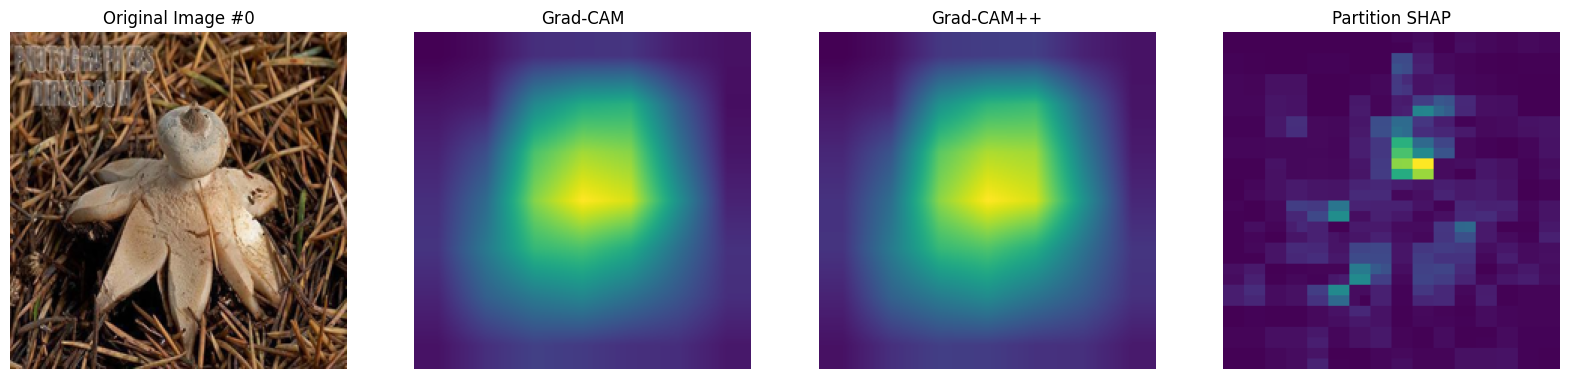

------------------------------------------------------------


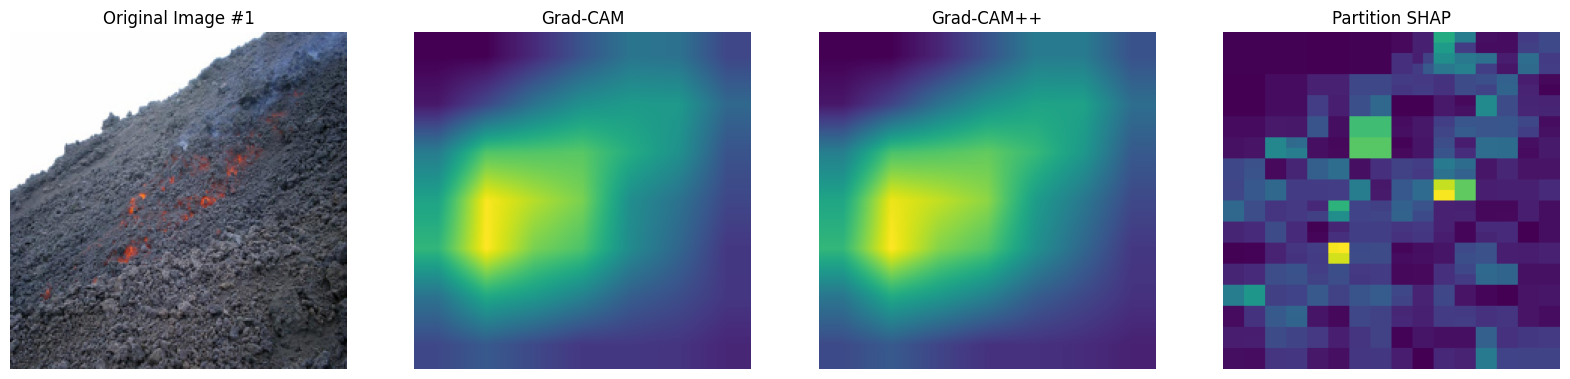

------------------------------------------------------------


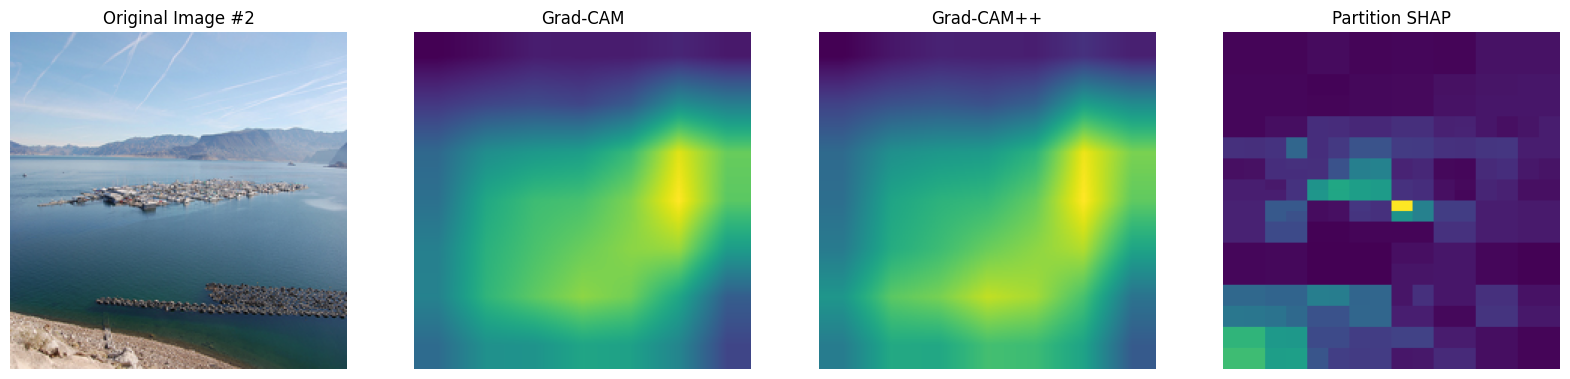

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Final Visual Diagnosis ---

def compare_heatmaps(img_index):
    """
    Displays the original image and the heatmaps from all three methods.
    """
    # Ensure all vectors are normalized for proper visualization
    def normalize_for_viz(vector):
        v_min, v_max = np.min(vector), np.max(vector)
        if v_max > v_min:
            return (vector - v_min) / (v_max - v_min)
        return vector # Avoid division by zero if flat

    # Get the data for the specified image
    original_image = images[img_index]
    gradcam_map = normalize_for_viz(gradvec_pixel[img_index]).reshape(224, 224)
    gradcampp_map = normalize_for_viz(gradppvec_pixel[img_index]).reshape(224, 224)
    shap_map = normalize_for_viz(partvec_pixel[img_index]).reshape(224, 224)

    # Create the plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(original_image)
    axes[0].set_title(f"Original Image #{img_index}")
    axes[0].axis('off')

    axes[1].imshow(gradcam_map, cmap='viridis')
    axes[1].set_title("Grad-CAM")
    axes[1].axis('off')

    axes[2].imshow(gradcampp_map, cmap='viridis')
    axes[2].set_title("Grad-CAM++")
    axes[2].axis('off')

    axes[3].imshow(shap_map, cmap='viridis')
    axes[3].set_title("Partition SHAP")
    axes[3].axis('off')

    plt.show()

# Visualize the results for the first few images
for i in range(3):
    print("-" * 60)
    compare_heatmaps(i)

In [ ]:
out=multcorr(partvec_pixel_norm,gradcam_vectors_norm,gradcampp_vectors_norm)
out

[[0.5035197361446294, 0.9991053710046651, 0.9991055728519602],
 [0.38273128114282934, 0.9974616085739948, 0.9974820543842515],
 [0.247209605895863, 0.9865077819279188, 0.9866210973092234],
 [0.34683086830096765, 0.9954057885274717, 0.9953586722602767],
 [0.4580798338582987, 0.9938054677520671, 0.9936415064034327],
 [0.4965184584818411, 0.992344708285698, 0.9920824039603882],
 [0.3723729197684911, 0.9482960384179014, 0.9492998592412144],
 [0.5775627712995768, 0.9903835082487786, 0.9900358783134809],
 [0.4106047051743664, 0.9970863917432343, 0.997053808704877],
 [0.4227346466242571, 0.9977621569581686, 0.9977804739986057],
 [0.32521879414664334, 0.9457762021680888, 0.943715293096065],
 [0.42374822492136394, 0.9943867609993152, 0.9944380854227219],
 [0.4657837827257353, 0.9949515087802996, 0.9949552606547682],
 [0.4583603054395622, 0.9968948565705029, 0.9968773206137604],
 [0.5222824963044523, 0.9915016612466712, 0.9916395552142944],
 [0.6400490899175149, 0.9899472351724964, 0.98973626764

In [ ]:
iout=[]
for i in range(100):
  x=np.argsort(out[i])[::-1][:1024]
  iout.append(x)
iout

[array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([1, 2, 0]),
 array([1, 2, 0]),
 array([2, 1, 0]),
 array([2, 1, 0]),
 array([2, 1

In [ ]:
#making 0as 1, 1as 2 ...
iout1=[]
for i in range(100):
  temp=iout[i]
  t=[x+1 for x in temp]
  iout1.append(t)
iout1

[[np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(3), np.int64(2), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(2), np.int64(3), np.int64(1)],
 [np.int64(3), np.int64(2), np.int

In [ ]:
def borda_count(votes):
    num_candidates = len(votes[0])
    scores = {candidate: 0 for candidate in range(1, num_candidates + 1)}

    for ballot in votes:
        for index, candidate in enumerate(ballot):
            scores[candidate] += num_candidates - index - 1

    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_scores

In [ ]:
ballots=iout1
result = borda_count(ballots)
print("Borda Count Result:")
for candidate, score in result:
    print(f"Candidate {candidate}: {score} points")

Borda Count Result:
Candidate 3: 159 points
Candidate 2: 141 points
Candidate 1: 0 points


In [ ]:
#final ranking - Multiple correlation
#based borda count ranking
borda_rank=[]
for candidate, score in result:
    borda_rank.append(candidate)
borda_rank

[3, 2, 1]

In [ ]:
import numpy as np
from scipy.stats import spearmanr

# Assume 'part_shap_values', 'gradvec_pixel', and 'gradppvec_pixel' are already calculated.

# --- 1. Process Partition SHAP Values (TensorFlow Method) ---

print("Processing Partition SHAP values using the TensorFlow notebook's method...")
# The original notebook used only the red channel and zeroed out negative values.
N = len(part_shap_values)
partvec_tf_method = np.zeros((N, 224 * 224), dtype=np.float32)

for i in range(N):
    # Get raw SHAP values for the i-th image, for the first (and only) explained class
    raw_values = part_shap_values.values[i]

    # Ensure shape is (h, w, c)
    if raw_values.ndim == 4:
        raw_values = raw_values[..., 0] # Handle (h,w,c,1) case

    # Select the RED channel only
    red_channel_values = raw_values[..., 0]

    # Set negative values to zero
    red_channel_values[red_channel_values < 0] = 0

    # Flatten and store
    partvec_tf_method[i] = red_channel_values.flatten()

print(f"SHAP processing complete. Shape: {partvec_tf_method.shape}")


# --- 2. Convert All Explanation Vectors to Ranks ---

print("\nConverting all explanation vectors to ranks using argsort...")
# This is the most critical step from the original notebook.
# We convert the matrices of values into matrices of ranks.
gradcam_ranks = gradvec_pixel.argsort(axis=1).argsort(axis=1)
gradcampp_ranks = gradppvec_pixel.argsort(axis=1).argsort(axis=1)
shap_ranks = partvec_tf_method.argsort(axis=1).argsort(axis=1)

print("Conversion to ranks complete.")


# --- 3. Perform Borda Count on Rank Vectors ---

print("\nPerforming Borda Count on the RANK vectors...")
candidate_names = ['Partition SHAP', 'Grad-CAM', 'Grad-CAM++']
all_vectors = [shap_ranks, gradcam_ranks, gradcampp_ranks] # Use the rank vectors

borda_scores = np.zeros(len(all_vectors), dtype=int)
num_images = all_vectors[0].shape[0]

for i in range(num_images):
    # Get the rank vectors for the current image
    vecs = [v[i] for v in all_vectors]

    # Calculate the pairwise Spearman correlation matrix for the ranks
    corr_matrix = np.corrcoef(np.array(vecs))

    # Get the sum of correlations for each candidate
    corr_sums = corr_matrix.sum(axis=1)

    # Get the ranks of the correlation sums (higher sum = better rank)
    ranks = len(corr_sums) - corr_sums.argsort().argsort() - 1

    # Assign Borda points (2 for 1st, 1 for 2nd, 0 for 3rd)
    borda_points = (len(ranks) - 1) - ranks
    borda_scores += borda_points

# --- 4. Display Final Results ---
print("\n" + "="*30)
print("  Final Borda Count Result")
print("="*30)

# Sort and print the results
sorted_indices = np.argsort(borda_scores)[::-1]
for idx in sorted_indices:
    print(f"Candidate {idx+1} ({candidate_names[idx]}): {borda_scores[idx]} points")

Processing Partition SHAP values using the TensorFlow notebook's method...
SHAP processing complete. Shape: (100, 50176)

Converting all explanation vectors to ranks using argsort...
Conversion to ranks complete.

Performing Borda Count on the RANK vectors...

  Final Borda Count Result
Candidate 3 (Grad-CAM++): 156 points
Candidate 2 (Grad-CAM): 144 points
Candidate 1 (Partition SHAP): 0 points


### Borda Borda

In [ ]:
import numpy as np
from collections import defaultdict

# --- Your Custom Borda-Correlation-Borda Analysis ---

# Assume 'partvec_pixel', 'gradvec_pixel', and 'gradppvec_pixel' are your loaded data.
candidate_names = ['Partition SHAP', 'Grad-CAM', 'Grad-CAM++']
all_vectors = [partvec_pixel, gradvec_pixel, gradppvec_pixel]
num_images = all_vectors[0].shape[0]

# --- Helper Function: A standard Borda Count implementation ---
def borda_count(ballots):
    """Calculates the Borda count scores from a list of ballots."""
    scores = defaultdict(int)
    if not ballots:
        return []
    num_candidates = len(ballots[0])
    for ballot in ballots:
        for i, candidate in enumerate(ballot):
            scores[candidate] += (num_candidates - 1) - i
    return sorted(scores.items(), key=lambda item: item[1], reverse=True)


# --- Stage 1: Create a consensus rank for each image (Your `calculateborda` logic) ---
# For each image, we rank the pixels to create 3 "ballots" and find a consensus.
stage1_consensus_ranks = []
for i in range(num_images):
    # For image 'i', get the explanation from each method
    shap_vec = all_vectors[0][i]
    grad_vec = all_vectors[1][i]
    gradpp_vec = all_vectors[2][i]

    # The "ballots" here are the pixel rankings from each method
    image_ballots = [
        shap_vec.argsort().argsort(),
        grad_vec.argsort().argsort(),
        gradpp_vec.argsort().argsort()
    ]

    # This isn't a true Borda count, but it averages the ranks of the pixels
    consensus_pixel_ranks = np.mean(image_ballots, axis=0)
    stage1_consensus_ranks.append(consensus_pixel_ranks)

print(f"✅ Stage 1 complete. Generated {len(stage1_consensus_ranks)} consensus rank vectors.")


# --- Stage 2: Rank methods based on correlation to the consensus (Your `bordarankcorr` logic) ---
stage2_ballots = []
for i in range(num_images):
    # For image 'i', correlate each method with the consensus rank vector
    correlations = [
        np.corrcoef(all_vectors[0][i], stage1_consensus_ranks[i])[0, 1], # SHAP vs Consensus
        np.corrcoef(all_vectors[1][i], stage1_consensus_ranks[i])[0, 1], # Grad-CAM vs Consensus
        np.corrcoef(all_vectors[2][i], stage1_consensus_ranks[i])[0, 1]  # Grad-CAM++ vs Consensus
    ]

    # Get the order of candidates, from highest correlation to lowest
    ranked_indices = np.argsort(correlations)[::-1]

    # Create the ballot for this image (e.g., ['Grad-CAM', 'Grad-CAM++', 'Partition SHAP'])
    ballot = [candidate_names[idx] for idx in ranked_indices]
    stage2_ballots.append(ballot)

print(f"✅ Stage 2 complete. Generated {len(stage2_ballots)} final ballots.")
print(f"   Example Ballot for Image 0: {stage2_ballots[0]}")


# --- Final Borda Count: Aggregate results from Stage 2 ---
final_results = borda_count(stage2_ballots)


# --- Display Final Results ---
print("\n" + "="*40)
print("  Final Result (Your Custom Method)")
print("="*40)
for candidate, score in final_results:
    print(f"{candidate}: {score} points")

✅ Stage 1 complete. Generated 100 consensus rank vectors.
✅ Stage 2 complete. Generated 100 final ballots.
   Example Ballot for Image 0: ['Grad-CAM++', 'Grad-CAM', 'Partition SHAP']

  Final Result (Your Custom Method)
Grad-CAM++: 169 points
Grad-CAM: 131 points
Partition SHAP: 0 points


In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_dir = "/content/drive/MyDrive/Imagenet 1000 samples"  # update this
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

image_paths = sorted([
    os.path.join(data_dir, f) for f in os.listdir(data_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

x_batch = torch.stack([transform(Image.open(p).convert("RGB")) for p in image_paths]).to(device)
print("Loaded batch shape:", x_batch.shape)


Loaded batch shape: torch.Size([1000, 3, 224, 224])


In [ ]:
import json
import urllib.request

url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
imagenet_classes = json.load(urllib.request.urlopen(url))

# Map indices to human-readable names
idx_to_label = {int(k): v[1] for k, v in imagenet_classes.items()}


In [ ]:
import torchvision.models as models
import torch.nn.functional as F
from torchvision.models import DenseNet121_Weights

weights = DenseNet121_Weights.IMAGENET1K_V1
model_softmax = models.densenet121(weights=weights).to(device)
model_softmax.eval()

with torch.no_grad():
    outputs = model_softmax(x_batch)
    y_batch = outputs.argmax(dim=1)  # predicted labels
    probs = F.softmax(outputs, dim=1)


In [ ]:
for i in range(5):
    pred_idx = y_batch[i].item()
    print(f"Image {i}: {idx_to_label[pred_idx]} (class {pred_idx})")


Image 0: tench (class 0)
Image 1: goldfish (class 1)
Image 2: great_white_shark (class 2)
Image 3: tiger_shark (class 3)
Image 4: swimming_trunks (class 842)


In [ ]:
import numpy as np
import quantus
from quantus.metrics import MaxSensitivity

# If your tensors are on GPU, move to CPU + NumPy:
x_np = x_batch.detach().cpu().numpy()
y_np = y_batch.detach().cpu().numpy()

metric = MaxSensitivity(
    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="Saliency", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Max-Sensitivity scores:", scores)




Evaluation complete!
Max-Sensitivity scores: [0.7422270774841309, 0.801990807056427, 0.7613113522529602, 0.8437598347663879, 0.7553224563598633, 0.7603917121887207, 0.6861677169799805, 0.765846848487854, 0.7372296452522278, 0.746728777885437, 0.7129930257797241, 0.7787959575653076, 0.7570933103561401, 0.8609897494316101, 0.814614474773407, 0.7997731566429138, 0.7503873109817505, 0.7621628642082214, 0.7106972336769104, 0.817514181137085, 0.7318524718284607, 0.7350649833679199, 0.7810194492340088, 0.7707631587982178, 0.7420037388801575, 0.6623030304908752, 0.805993378162384, 0.802460789680481, 0.8481018543243408, 1.2055888175964355, 0.7976923584938049, 0.7980563044548035, 0.7617495059967041, 0.7828465700149536, 0.6587511897087097, 0.6984493136405945, 0.7874336242675781, 0.7039794325828552, 0.6373022794723511, 0.6906805038452148, 0.8065449595451355, 0.8037183284759521, 0.7317342162132263, 0.8300552368164062, 0.6426272392272949, 0.8083202838897705, 0.7629274725914001, 0.6934534311294556, 

In [ ]:
np.average(scores)

0.7643489862084388

In [ ]:
np.std(scores)

0.06619008656613183

In [ ]:
np.mean(scores)

0.7643489862084388

In [ ]:
from scipy import stats

# Calculate the standard error of the mean
sem = stats.sem(scores)

# Calculate the confidence interval (e.g., 95% confidence interval)
confidence_level = 0.95
degrees_freedom = len(scores) - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=np.mean(scores), scale=sem)

print(f"95% Confidence Interval for Max-Sensitivity scores: {confidence_interval}")

95% Confidence Interval for Max-Sensitivity scores: (0.7602395259499155, 0.7684584464669622)


In [ ]:
metric = MaxSensitivity(    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores1 = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="GradientShap", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Max-Sensitivity scores:", scores1)



Evaluation complete!
Max-Sensitivity scores: [1.0382733345031738, 3.1682498455047607, 93.50216674804688, 13306.1279296875, 4621544.5, 16758.619140625, 203.22496032714844, 51.49724578857422, 34.39607620239258, 57.64154815673828, 1.0687108039855957, 12869.361328125, 628.8021850585938, 20081.87109375, 1.0283236503601074, 0.9999839067459106, 6.88982629776001, 74.1856918334961, 1.9425938129425049, 8.598780632019043, 9.393165588378906, 3.8101139068603516, 1.1896847486495972, 3257.522705078125, 1.1395559310913086, 2.2159881591796875, 2.4733052253723145, 0.9948830604553223, 162.52296447753906, 1.6236414909362793, 1.7515298128128052, 19.92820167541504]


In [ ]:
np.average(scores1)

146537.2821827419

In [ ]:
from quantus.metrics import LocalLipschitzEstimate
metric2 = LocalLipschitzEstimate(    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores1 = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="GradientShap", device=device),
    device=device
)

print("\nEvaluation complete!")
print("LocalLipschitzEstimate:", scores1)


Evaluation complete!
LocalLipschitzEstimate: [1.3633016347885132, 1.2647006511688232, 1.4274849891662598, 2.014169931411743, 2.2659401893615723, 1.4875638484954834, 1.906578779220581, 2.159661293029785, 1.7929614782333374, 1.2084927558898926, 1.5521482229232788, 1.8982421159744263, 3.8716535568237305, 1.313294768333435, 1.278637170791626, 3.1080636978149414, 2.560333490371704, 1.5671918392181396, 1.0085722208023071, 2.8627827167510986, 1.1268502473831177, 4.259360313415527, 1.1996501684188843, 2.472400426864624, 2.3424901962280273, 2.7627511024475098, 2.4712977409362793, 1.3833955526351929, 1.933220386505127, 3.6126773357391357, 1.6179310083389282, 1.5206644535064697, 1.2851839065551758, 1.1835018396377563, 1.084837555885315, 1.9221373796463013, 2.1290063858032227, 1.8104586601257324, 3.0042812824249268, 1.4954975843429565, 1.9746403694152832, 1.318690538406372, 2.1818130016326904, 1.423989176750183, 2.131162405014038, 1.6529234647750854, 2.9327661991119385, 1.6380172967910767, 1.0830

In [ ]:
np.average(scores1)

1.662012249290943

In [ ]:
np.std(scores1)

0.5495402815747725

In [ ]:
from scipy import stats

# Calculate the standard error of the mean
sem = stats.sem(scores1)

# Calculate the confidence interval (e.g., 95% confidence interval)
confidence_level = 0.95
degrees_freedom = len(scores1) - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=np.mean(scores1), scale=sem)

print(f"95% Confidence Interval for Max-Sensitivity scores: {confidence_interval}")

95% Confidence Interval for Max-Sensitivity scores: (1.6278936362969423, 1.6961308622849438)


In [ ]:
metric2 = LocalLipschitzEstimate(    nr_samples=10,              # <-- correct kwarg
    disable_warnings=True
)

scores = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="Saliency", device=device),
    device=device
)

print("\nEvaluation complete!")
print("LocalLipschitzEstimate:", scores)


Evaluation complete!
LocalLipschitzEstimate: [0.7525809407234192, 0.8027753829956055, 0.7596070766448975, 0.8220056295394897, 0.7433319687843323, 0.7584347128868103, 0.7251184582710266, 0.7591257095336914, 0.7521710395812988, 0.7752063274383545, 0.7292771339416504, 0.7829604148864746, 0.7613931894302368, 0.8722885251045227, 0.8108875751495361, 0.8527883291244507, 0.7312688231468201, 0.769024670124054, 0.7125248312950134, 0.8256949186325073, 0.7641401290893555, 0.7031062841415405, 0.7748523354530334, 0.7716502547264099, 0.7514290809631348, 0.67021644115448, 0.8000887036323547, 0.7702874541282654, 0.8234111070632935, 0.8892987966537476, 0.7855187654495239, 0.8227136135101318, 0.7479709982872009, 0.8005305528640747, 0.6736390590667725, 0.7113078832626343, 0.8170531988143921, 0.6845059394836426, 0.6252609491348267, 0.7271406054496765, 0.8227713704109192, 0.6915631294250488, 0.7155348658561707, 0.8764873147010803, 0.641376256942749, 0.7694564461708069, 0.7577717900276184, 0.687038183212280

In [ ]:
np.average(scores)

0.7636493458151817

In [ ]:
np.std(scores)

0.06574240194555238

In [ ]:
from scipy import stats

# Calculate the standard error of the mean
sem = stats.sem(scores)

# Calculate the confidence interval (e.g., 95% confidence interval)
confidence_level = 0.95
degrees_freedom = len(scores) - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=np.mean(scores), scale=sem)

print(f"95% Confidence Interval for Max-Sensitivity scores: {confidence_interval}")

95% Confidence Interval for Max-Sensitivity scores: (0.7595676803859458, 0.7677310112444177)


In [ ]:
from quantus.metrics import Sufficiency
metric3 = Sufficiency(           # <-- correct kwarg
    disable_warnings=True
)

scores2 = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="Saliency", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Sufficiency:", scores2)


Evaluation complete!
Sufficiency: [0.7496650815010071, 0.7887296676635742, 0.7536359429359436, 0.8734096884727478, 0.7446339130401611, 0.7695093750953674, 0.7661034464836121, 0.7580194473266602, 0.7350456714630127, 0.7571746110916138, 0.7181842923164368, 0.7679686546325684, 0.7629010081291199, 0.9097992181777954, 0.8139703273773193, 0.8032960891723633, 0.721184253692627, 0.774070680141449, 0.7085360884666443, 0.8205705285072327, 0.7544920444488525, 0.8514385223388672, 0.7782002687454224, 0.7866215109825134, 0.7442870140075684, 0.692939817905426, 0.8174464106559753, 0.8117959499359131, 0.8469900488853455, 0.9158884286880493, 0.7888773679733276, 0.802336573600769, 0.7706137895584106, 0.7901129126548767, 0.6657257080078125, 0.7081197500228882, 0.7939776182174683, 0.6889939904212952, 0.6120980381965637, 0.7218020558357239, 0.8077602386474609, 0.7780357599258423, 0.7164672017097473, 1.0989620685577393, 0.6489971280097961, 0.7869977355003357, 0.7537868618965149, 0.6910675168037415, 0.701939

In [ ]:
np.average(scores2)

0.764512596309185

In [ ]:
np.std(scores2)

0.06527254439026597

In [ ]:
from scipy import stats

# Calculate the standard error of the mean
sem = stats.sem(scores2)

# Calculate the confidence interval (e.g., 95% confidence interval)
confidence_level = 0.95
degrees_freedom = len(scores2) - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=np.mean(scores2), scale=sem)

print(f"95% Confidence Interval for Max-Sensitivity scores: {confidence_interval}")

95% Confidence Interval for Max-Sensitivity scores: (0.7604601023322131, 0.7685650902861569)


In [ ]:
metric3 = Sufficiency(           # <-- correct kwarg
    disable_warnings=True
)

scores4 = metric(
    model=model_softmax,
    x_batch=x_np,
    y_batch=y_np,
    explain_func=quantus.explain,   # recompute attributions under perturbations
    explain_func_kwargs=dict(method="GradientShap", device=device),
    device=device
)

print("\nEvaluation complete!")
print("Sufficiency:", scores4)


Evaluation complete!
Sufficiency: [3.597053050994873, 2.3946352005004883, 1.4455769062042236, 1.667189121246338, 1.908673644065857, 1.3568189144134521, 1.4343255758285522, 3.2159013748168945, 1.9188716411590576, 1.1571675539016724, 1.5904370546340942, 2.0365402698516846, 1.6890889406204224, 1.1493544578552246, 1.5530574321746826, 3.878948450088501, 1.0370919704437256, 1.4368126392364502, 1.3154934644699097, 1.7705669403076172, 3.3574211597442627, 2.732283353805542, 1.204557180404663, 1.063218116760254, 1.1072331666946411, 2.0668346881866455, 2.2272462844848633, 1.6064765453338623, 2.03800106048584, 3.789396047592163, 1.3027530908584595, 1.5022757053375244, 1.6303633451461792, 1.308143138885498, 3.3811283111572266, 1.019768238067627, 1.5949496030807495, 2.2225751876831055, 1.0894629955291748, 1.424333930015564, 1.8950251340866089, 2.4763126373291016, 1.4985620975494385, 1.5335317850112915, 1.0691524744033813, 1.314450740814209, 1.908332347869873, 1.485642910003662, 1.2803306579589844, 

In [ ]:
np.average(scores4)

1.6766727772951127

In [ ]:
np.std(scores4)

0.5520478880482657

In [ ]:
from scipy import stats

# Calculate the standard error of the mean
sem = stats.sem(scores4)

# Calculate the confidence interval (e.g., 95% confidence interval)
confidence_level = 0.95
degrees_freedom = len(scores4) - 1
confidence_interval = stats.t.interval(confidence_level, degrees_freedom, loc=np.mean(scores4), scale=sem)

print(f"95% Confidence Interval for Max-Sensitivity scores: {confidence_interval}")

95% Confidence Interval for Max-Sensitivity scores: (1.6423984777069185, 1.7109470768833068)
